https://ollama.com/library/llama3.2

```bash
ollama pull llama3.2:latest
``` 

In [4]:
from ollama import Client
import json

MODEL = 'llama3.2:latest'


class ChatModel:
    def __init__(self, top_p=1.0, temperature=0.5, output_length=3000):
        self.client = Client(host='http://localhost:11434')
        self.top_p = top_p
        self.temperature = temperature
        self.output_length = output_length


    def set_parameters(self, top_p=1.0, temperature=0.5):
        self.top_p = top_p
        self.temperature = temperature


    def complete(self, prompt: str, system: str = ""):
        messages = []
        if system:
            messages.append({'role': 'system', 'content': system})
        messages.append({'role': 'user', 'content': prompt})

        response = self.client.chat(
            model=MODEL,
            messages=messages,
            options={
                'temperature': self.temperature,
                'top_p': self.top_p,
                'num_predict': self.output_length
            }
        )
        return response.message.content


    def complete_structured(self, prompt: str, schema: dict, system: str = ""):
        messages = []
        if system:
            messages.append({'role': 'system', 'content': system})
        messages.append({'role': 'user', 'content': prompt})

        response = self.client.chat(
            model=MODEL,
            messages=messages,
            format=schema,
            options={
                'temperature': self.temperature,
                'top_p': self.top_p,
                'num_predict': self.output_length
            }
        )
        return response.message.content


# 1. Introduzione al Prompt Engineering

Il Prompt Engineering è l'arte e (forse) la scienza di progettare input efficaci (prompt) per i modelli di linguaggio di grandi dimensioni (LLM) al fine di ottenere output desiderati e di alta qualità. 

Negli ultimi anni è diventato una competenza fondamentale nell'era dell'intelligenza artificiale generativa.

## 1.2 Perché è importante?
- **Massimizzare l'efficacia**: Un prompt ben strutturato può fare la differenza tra una risposta generica e una soluzione precisa
- **Controllo dell'output**: Permette di guidare il modello verso risultati specifici
- **Migliorare l'affidabilità**: Prompt ben progettati producono risultati più consistenti
- **Ridurre i costi**: Prompt efficienti riducono il numero di iterazioni necessarie

## 1.3 Applicazioni pratiche

- Automazione di task ripetitivi
- Assistenti virtuali personalizzati
- Generazione di contenuti
- Analisi di dati
- Sviluppo software assistito
- Traduzione e localizzazione

---

# 2. Impostazioni LLM

Per padroneggiare le tecniche di prompt engineering è fondamentale comprendere i parametri che influenzano il comportamento dei modelli linguistici. Elementi come la temperatura, la top-p, il numero massimo di token e la penalizzazione della frequenza incidono direttamente sulla qualità, coerenza e creatività delle risposte generate. Avere familiarità con questi parametri consente un maggiore controllo sull’output del modello e permette di adattarlo meglio agli obiettivi specifici dell’interazione.

## 2.1 Temperatura

La temperatura controlla la casualità e la creatività delle risposte generate dal modello.
Tipicamente il range va da un minimo di 0.0 a un massimo di 2.0.

**Caratteristiche**:
- **Bassa temperatura (0.0 - 0.3)**
Output più deterministico, prevedibile e focalizzato. Da utilizzare per: analisi tecniche, estrazione di informazioni, risposte fattuali
- **Media temperatura (0.5 - 0.8)**
Bilanciamento tra creatività e coerenza. Da utilizzare per: scrittura generale, conversazioni
- **Alta temperatura (1.0 - 2.0)**
Output più creativo, variato ma potenzialmente meno coerente. Da utilizzare per: contenuti creativi, brainstorming, generazione di idee




![alt text](temperature_comparison.png)

In [ ]:
def chat_temperature(temperature):
    message = "Explain quantum computing in simple terms"

    model = ChatModel(temperature = temperature)
    print(model.complete(message))

In [ ]:
chat_temperature(temperature=0.5)

## 2.2 Top_P

Il Top P (anche chiamato nucleus sampling) è un metodo alternativo per controllare la casualità delle risposte. Il modello considera solo i token la cui probabilità cumulativa raggiunge il valore di top_p. 

Ad esempio:
- Top P = 0.1: considera solo il 10% dei token più probabili
- Top P = 0.9: considera il 90% dei token più probabili

Mentre la temperatura modifica la distribuzione di probabilità del risultato, Top_P limita il numero di token da considerare.

Generalmente si consiglia di modificare uno solo dei due parametri.

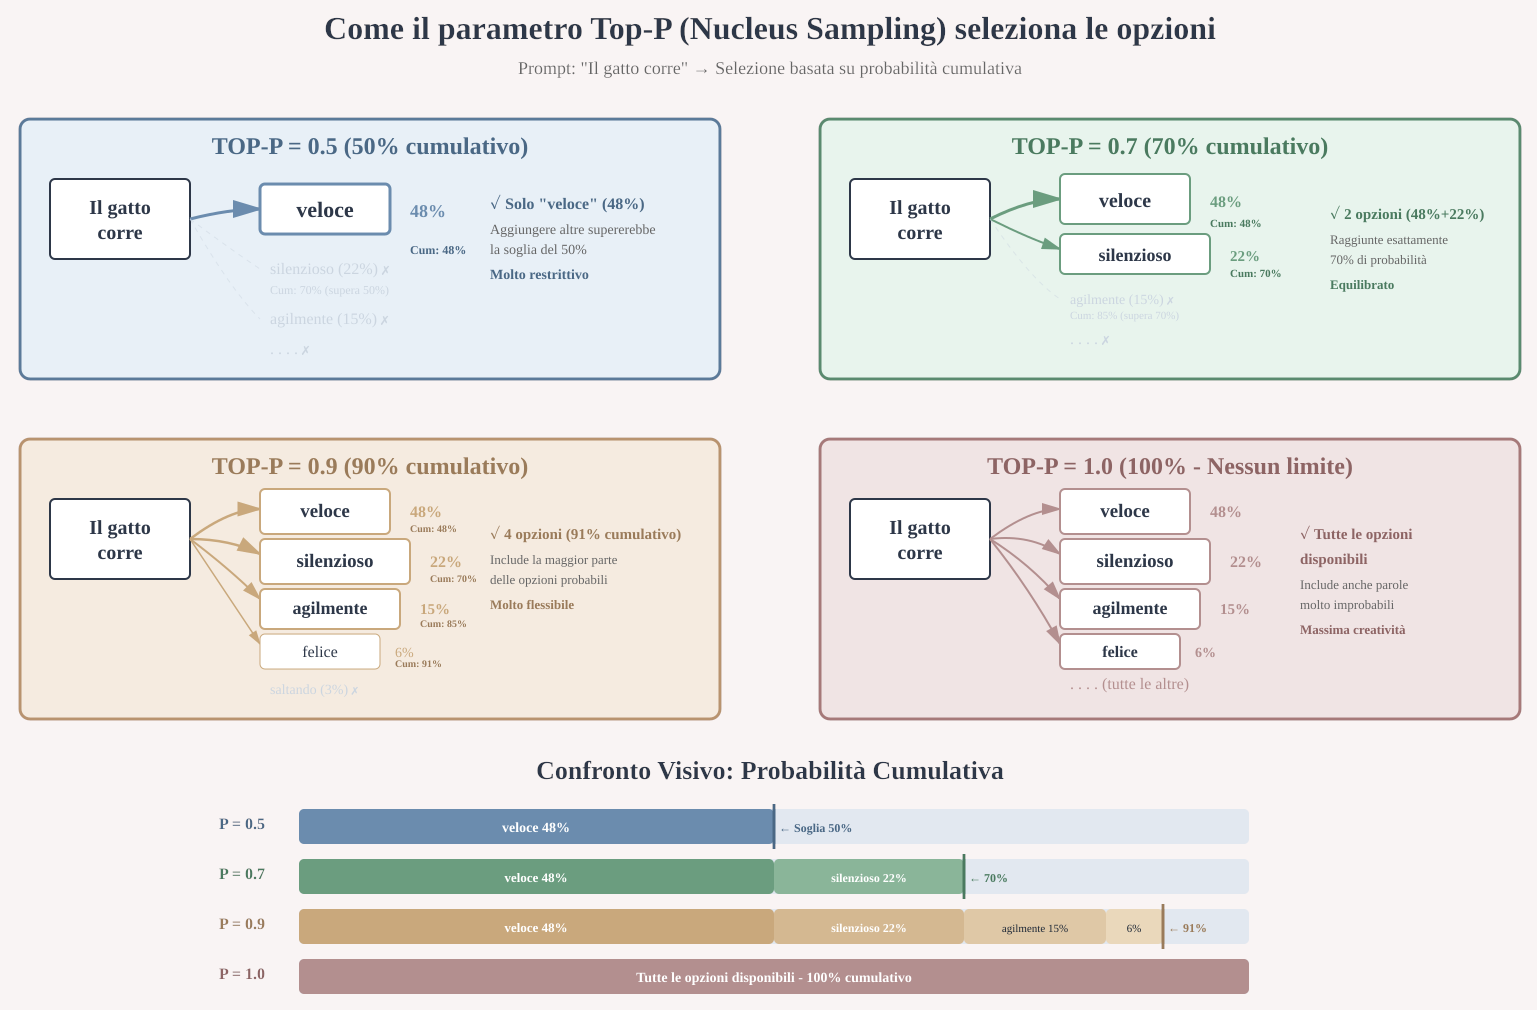

In [ ]:
def chat_top_p(top_p):
    message = "Explain quantum computing in simple terms"

    model = ChatModel(top_p = top_p)
    print(model.complete(message))

In [ ]:
chat_top_p(top_p = 0.2)

## 2.3 Max Tokens output

- Limita la lunghezza massima della risposta
- Utile per controllare i costi e mantenere risposte concise

In [ ]:
def chat_output_length(length):
    message = f"Explain quantum computing in simple terms. Use less than {length} tokens."

    model = ChatModel(output_length = length)
    print(model.complete(message))

In [ ]:
chat_output_length(100)

# 3. Elementi di un Prompt

Un prompt efficace è composto da diversi elementi che lavorano insieme per guidare il modello verso l'output desiderato.

## 3.1 Formato e stile
- Il formato Markdown è ormai diventato uno **standard de facto** nella stesura dei prompt.
- I delimitatori aiutano il modello a distinguere tra istruzioni e dati.
    - Triple virgolette: """
    - Tag XML: <text></text>
    - Marcatori: ###, ---
    - Backticks: `


## 3.2 Elementi

- **CONTEXT**

    Il **contesto** fornisce informazioni aggiuntive che aiutano il modello a comprendere meglio il task.

    **Caratteristiche:**
    - Background information
    - Informazioni di dominio specifiche
    - Vincoli o requisiti particolari

    **Esempio:**

    ```markdown
    # CONTEXT
    You are a financial analyst with expertise in the tech sector. 
    The following quarterly report is from a startup company.
    ```

- **INSTRUCTION**

    L'**istruzione** è il compito specifico che si vuole far eseguire al modello.

    **Caratteristiche:**
    - Deve essere chiara e specifica
    - Utilizza verbi d'azione (es. "Analyze", "Summarize", "Translate")
    - Definisce cosa deve fare il modello

    **Esempio:**
    ```markdown
    # INSTRUCTION
    Analyze the sentiment of the following customer review
    ```

- **INPUT DATA**

    I **dati di input** sono le informazioni specifiche su cui il modello deve lavorare.

    **Caratteristiche:**
    - I pezzi di documenti, storico chat, codice o dati da analizzare
    - Può essere separato visualmente con delimitatori

    **Esempio:**
    ```markdown
    # INPUT
    Analyze the following documents:
    {input_data}
    ```

- **OUTPUT INDICATORS**

    Gli **indicatori di output** specificano il formato o la struttura desiderata della risposta.

    **Caratteristiche:**
    - Formato della risposta (JSON, markdown, lista, etc.)
    - Lunghezza desiderata
    - Stile o tono

    **Esempio:**
    ```markdown
    # OUTPUT
    Provide your answer in JSON format with the following structure:
    {
        "sentiment": "positive/negative/neutral",
        "confidence": 0-100,
        "key_phrases": []
    }
    ```

In [ ]:
def chat_prompt_1():
    message = prompt = """
    # CONTEXT
    You are an expert data analyst specializing in customer feedback analysis.

    # INSTRUCTION
    Task: Analyze the sentiment and extract key themes from the following product review.

    # INPUT
    Review: "I purchased this laptop two weeks ago and I'm thoroughly impressed. 
    The battery life is exceptional - I can work for 10 hours straight without charging. 
    However, the trackpad is a bit too sensitive for my liking. Overall, great value for money."

    # OUTPUT
    Respond only using the following json object schema:
    {
      "overall_sentiment": [positive/negative/neutral]
      "confidence_score": [0-100]
      "key_themes": [list of themes]
      "pros": [list]
      "cons": [list]
    }
    """

    model = ChatModel()
    print(model.complete(message))

In [ ]:
chat_prompt_1()

# 4. Tecniche di Prompt base

Le tecniche di base includono:

- Zero-shot / Few-shot prompting 

- Chain-of-Thought prompting
  

Queste strategie si basano sull’idea che la **forma del prompt** influisce in modo significativo sulla qualità e accuratezza della risposta.



## 4.1 Zero-Shot  / Few-Shot  Prompting

Queste prime tecniche di prompt engineering nascono dai primi studi effettuati sui risultati dei transformer.

   https://arxiv.org/abs/2005.14165

- Il **zero-shot prompting** consiste nel fornire al modello un’istruzione chiara e diretta, senza esempi precedenti.
Il modello deve generalizzare la risposta solo sulla base della descrizione del compito.


    - **Vantaggi**
        - Semplice da progettare
        - Nessun bisogno di esempi espliciti

    - **Limiti**
        - Performance più basse per compiti complessi
        - Sensibile alla formulazione linguistica del prompt


- Il **few-shot prompting** prevede l’inclusione di alcuni esempi di input-output nel prompt, in modo che il modello possa apprendere implicitamente il formato e la logica del compito prima di generare la risposta.

    - **Vantaggi**
        - Maggiore accuratezza e controllo sul formato della risposta
        - Utile per compiti strutturati (estrazione dati, classificazione, traduzione, ecc.)

    - **Limiti**
        - Maggiore lunghezza del prompt → più costi in token
        - Esempi poco coerenti possono ridurre la qualità dell’output

In [ ]:
ZERO_SHOT_PROMPT = \
"""
# INSTRUCTION
Translate the following English sentence into Italian:

# INPUT
"The cat is sleeping under the table."
"""

FEW_SHOT_PROMPT = \
"""
# INSTRUCTION
Classify customer feedback as POSITIVE, NEGATIVE, or NEUTRAL.

# EXAMPLES
Feedback: "The service was exceptional and the staff was very helpful!"
Classification: POSITIVE

Feedback: "Terrible experience. Long wait times and rude staff."
Classification: NEGATIVE

Feedback: "The product arrived on time and matches the description."
Classification: NEUTRAL

Now classify this feedback:
Feedback: The product broke after one day. Very disappointed.
"""



In [ ]:
def chat_zero_few_shots(prompt):

    model = ChatModel(top_p = 1.0, 
                      temperature = 0.5, 
                      output_length = 3000)
    print(model.complete(prompt))

In [ ]:
chat_zero_few_shots(ZERO_SHOT_PROMPT)

In [ ]:
chat_zero_few_shots(FEW_SHOT_PROMPT)


## 4.2 Chain-of-Thought (CoT) Prompting

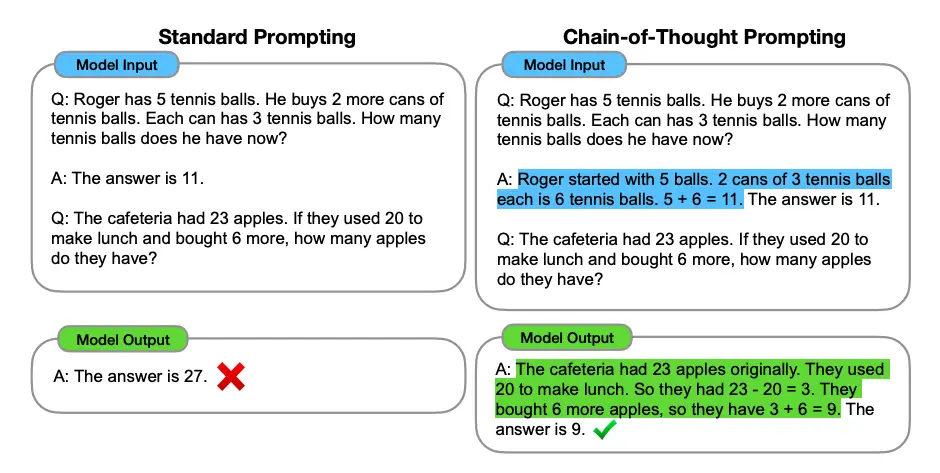

Il **Chain-of-Thought (CoT) Prompting** incoraggia il modello a scomporre problemi complessi in passaggi intermedi di ragionamento prima di fornire la risposta finale.

Questo approccio migliora le prestazioni su compiti di ragionamento logico, matematico e deduttivo.

- **Vantaggi**
    - Migliora la predizione di token su un task specifico e la trasparenza del modello
    - Riduce gli errori in problemi matematici e logici
    - Viene usato durante il fine-tuning per impostare modelli di ragionamento corretti

- **Limiti**
    - Output più lunghi
    - Potenziale “overthinking” su compiti semplici
    - Rischio di ragionamenti intermedi errati che portano a risposte sbagliate

### 4.2.1 Fondamenti Teorici

Il Chain-of-Thought è stato introdotto nel paper "Chain-of-Thought Prompting Elicits Reasoning in Large Language Models" (Wei et al., 2022, Google Research).

 https://arxiv.org/abs/2201.11903

 Scoperte chiave:

- I modelli possono *"ragionare"* meglio se mostrano i passaggi intermedi
- L'accuratezza migliora significativamente su task composti da processi logici e sequenziali
- L'effetto è più pronunciato con modelli più grandi (100B+ parametri)
- L'uso di formule come "let's think step-by-step" alla fine del prompt,  costituiscono dei trigger per questo tipo di proprietà emergente.

```
INPUT → RAGIONAMENTO STEP-BY-STEP → OUTPUT

Invece di:
Q: "Quanto fa 23 * 47?"
A: "1081"

Con CoT:
Q: "Quanto fa 23 * 47?"
A: "Scompongo il calcolo:
    Step 1: 23 * 40 = 920
    Step 2: 23 * 7 = 161
    Step 3: 920 + 161 = 1081
    Risposta finale: 1081"
```

### 4.2.2 Tecniche di Base CoT


####  Zero-Shot Chain-of-Thought

La forma più semplice: aggiungere "Let's think step by step" alla fine del prompt.

In [ ]:
def chat_cot(cot: str = ""):

    model = ChatModel(top_p = 1.0, 
                      temperature = 0.5, 
                      output_length = 3000)
    
    question = "If a train travels 120.5 km in 2.30 hours, \
                then 180.43 km in 3.30 hours, what is its average speed?\n"

    print(model.complete(question + cot))

In [ ]:
chat_cot()

In [ ]:
chat_cot("Let's think step by step:")

#### Varianti della Frase Trigger

In [ ]:
TRIGGER_PHRASES = {
    'standard': "Let's think step by step:",
    'detailed': "Let's solve this problem step by step with detailed explanations:",
    'methodical': "Let's approach this methodically:",
    'analytical': "Let's break this down and analyze each part:",
    'systematic': "Let's work through this systematically:"
}

In [ ]:
chat_cot(TRIGGER_PHRASES['standard'])

In [ ]:
chat_cot(TRIGGER_PHRASES['detailed'])

In [ ]:
chat_cot(TRIGGER_PHRASES['methodical'])

In [ ]:
chat_cot(TRIGGER_PHRASES['analytical'])

In [ ]:
chat_cot(TRIGGER_PHRASES['systematic'])

#### Few-Shot Chain-of-Thought

Fornisce esempi completi di ragionamento step-by-step.


In [ ]:
FEW_SHOT_COT = \
"""
# INSTRUCTION
Solve the following problems showing your reasoning step by step.

# EXAMPLES
Example 1:
Q: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. 
   Each can has 3 balls. How many tennis balls does he have now?
A: Let's think step by step:
   Step 1: Roger starts with 5 balls
   Step 2: He buys 2 cans, each with 3 balls: 2 × 3 = 6 balls
   Step 3: Total balls = 5 + 6 = 11 balls
   Answer: Roger has 11 tennis balls

Example 2:
Q: A cafeteria had 23 apples. If they used 20 to make lunch and bought 6 more, 
   how many apples do they have?
A: Let's think step by step:
   Step 1: Start with 23 apples
   Step 2: Used 20 apples: 23 - 20 = 3 apples left
   Step 3: Bought 6 more: 3 + 6 = 9 apples
   Answer: The cafeteria has 9 apples

# INPUT
Now solve this problem:
"""


def chat_few_shot_cot(cot: str = ""):

    model = ChatModel(top_p = 1.0, 
                      temperature = 0.5, 
                      output_length = 3000)
    
    message = "A bakery made 37 cookies. \
               They sold 19 in the morning and 12 in the afternoon. \
               How many cookies are left?\n"
    

    print(model.complete(FEW_SHOT_COT + message + cot))


In [ ]:
chat_few_shot_cot("# OUTPUT\n" + TRIGGER_PHRASES['standard'])

#### CoT con Template Strutturato

Progettazione manuale della struttura del ragionamento.

In [ ]:
def manual_cot_template(problem_type):
    templates = {
# ------------- MATH
        'math': """
Problem: {problem}

Solution Process:

1. UNDERSTAND THE PROBLEM
   - What is being asked?
   - What information is given?
   - What formula or method should we use?

2. PLAN THE SOLUTION
   - What steps are needed?
   - In what order?

3. EXECUTE
   - Perform each calculation
   - Show intermediate results

4. VERIFY
   - Does the answer make sense?
   - Check the calculation

Answer: [final answer]
""",
# ------------- LOGIC
        'logic': """
Problem: {problem}

Reasoning Process:

1. IDENTIFY KEY FACTS
   - List all given information
   - Note any assumptions

2. IDENTIFY THE QUESTION
   - What exactly needs to be determined?

3. APPLY LOGICAL RULES
   - What logical principles apply?
   - Draw intermediate conclusions

4. REACH CONCLUSION
   - Based on the reasoning above

Answer: [final answer]
""",
# ------------- ANALYSIS
        'analysis': """
Problem: {problem}

Analysis Framework:

1. CONTEXT
   - Background information
   - Relevant factors

2. BREAKDOWN
   - Divide into components
   - Examine each part

3. SYNTHESIS
   - How do parts relate?
   - What patterns emerge?

4. CONCLUSION
   - Main findings
   - Implications

Answer: [final answer]
"""
    }
    
    return templates.get(problem_type, templates['math'])

In [ ]:
def chat_manual_cot():

    model = ChatModel(top_p = 1.0, 
                      temperature = 0.5, 
                      output_length = 3000)
    
    problem_type='analysis'
    problem = """
A company's revenue increased from $2 million to $2.5 million (25% increase).
If costs increased from $1.5 million to $1.9 million, did the profit margin improve or worsen?
"""
    
    template = manual_cot_template(problem_type)
    prompt = template.format(problem=problem)
    
    print(model.complete(prompt))

chat_manual_cot()

# 5. System Prompt & Role Prompting

Il **system prompt** è un messaggio speciale inviato al modello *prima* della conversazione. Non è parte del dialogo visibile all'utente, ma definisce il comportamento, il contesto e i vincoli del modello per tutta la sessione.


## 5.1 System Prompt

**Caratteristiche:**
- Imposta **comportamento globale** valido per tutta la conversazione
- Definisce **lingua**, **tono** e **stile** delle risposte
- Stabilisce **vincoli** permanenti che l'utente non può sovrascrivere
- Fornisce **contesto di dominio** senza ripeterlo in ogni prompt

```
┌─────────────────────────────────────────────────────┐
│  SYSTEM:  "Sei un assistente finanziario esperto..." │  ← invisibile all'utente
├─────────────────────────────────────────────────────┤
│  USER:    "Analizza questo bilancio..."              │
├─────────────────────────────────────────────────────┤
│  ASSISTANT: risposta contestualizzata               │
└─────────────────────────────────────────────────────┘
```

In [ ]:
def chat_system_prompt(system: str, user_message: str):
    model = ChatModel(temperature=0.5)
    print("--- SYSTEM ---")
    print(system)
    print("--- USER ---")
    print(user_message)
    print("--- RESPONSE ---")
    print(model.complete(user_message, system=system))


# Senza system prompt
chat_system_prompt(
    system="",
    user_message="What is the risk of this investment?"
)

In [ ]:
# Con system prompt: contesto finanziario
chat_system_prompt(
    system=(
        "You are a conservative financial advisor specialized in risk management. "
        "Always highlight potential risks before benefits. "
        "Use precise financial terminology and provide numerical estimates where possible. "
        "Keep responses under 150 words."
    ),
    user_message="What is the risk of this investment?"
)

## 5.2 Role Prompting

Il **Role Prompting** assegna al modello una **persona** o **ruolo** specifico attraverso il system prompt, ottenendo risposte con il tono, le competenze e la prospettiva di quella figura.

**Pattern base:**
```markdown
You are a [RUOLO] with [N] years of experience in [DOMINIO].
Your communication style is [STILE].
You always [COMPORTAMENTO POSITIVO].
You never [COMPORTAMENTO DA EVITARE].
```

**Effetti del Role Prompting:**
- **Vocabolario** adattato al dominio del ruolo
- **Prospettiva** coerente con l'expertise dichiarata
- **Tono** e **stile** comunicativo specifici
- **Priorità** diverse nelle risposte (es. un medico vs un avvocato)

In [ ]:
ROLES = {
    'doctor': (
        "You are a general practitioner with 15 years of clinical experience. "
        "You explain medical concepts in clear, accessible language avoiding unnecessary jargon. "
        "You always recommend consulting a specialist for serious concerns."
    ),
    'lawyer': (
        "You are a corporate lawyer specializing in contract law. "
        "You are precise, cautious, and always highlight legal risks. "
        "You avoid definitive statements and always recommend professional consultation."
    ),
    'engineer': (
        "You are a senior software engineer with expertise in system design. "
        "You think in terms of trade-offs, scalability, and maintainability. "
        "You prefer concrete, technical answers with examples."
    )
}

QUESTION = "What are the main risks I should be aware of before signing a new contract?"

def chat_roles(roles: dict, question: str):
    model = ChatModel(temperature=0.5)
    for role_name, system in roles.items():
        print(f"\n{'='*60}")
        print(f"ROLE: {role_name.upper()}")
        print('='*60)
        print(model.complete(question, system=system))

chat_roles(ROLES, QUESTION)

## 5.3 Persona Composita

È possibile costruire system prompt strutturati che combinano più dimensioni del ruolo:
**identità**, **obiettivo**, **stile**, **vincoli**.

```markdown
## IDENTITY
You are Alex, a senior data scientist at a fintech startup.

## OBJECTIVE  
Help the team understand complex data patterns and translate them into business insights.

## COMMUNICATION STYLE
- Use analogies to explain technical concepts
- Always provide concrete numbers and examples
- Be direct and pragmatic

## CONSTRAINTS
- Never share raw data or PII
- Always mention confidence levels for predictions
- Flag data quality issues before drawing conclusions
```

In [ ]:
PERSONA = """
## IDENTITY
You are Alex, a senior data scientist at a fintech startup.

## OBJECTIVE
Help the team understand complex data patterns and translate them into business insights.

## COMMUNICATION STYLE
- Use analogies to explain technical concepts
- Always provide concrete numbers and examples
- Be direct and pragmatic, avoid over-explaining

## CONSTRAINTS
- Flag data quality issues before drawing conclusions
- Always mention confidence levels for predictions
- Keep responses under 200 words
"""

model = ChatModel(temperature=0.5)
print(model.complete(
    "We noticed a 40% spike in transaction failures last Tuesday between 2-4pm. What should we look at?",
    system=PERSONA
))

# 6. Structured Output

Per le applicazioni reali, ottenere output **garantito e parsabile** è fondamentale. Esistono due approcci:

| Approccio | Pro | Contro |
|---|---|---|
| **JSON nel testo** (sez. 3) | Semplice, funziona sempre | Il modello può aggiungere testo extra, JSON malformato |
| **Ollama `format` API** | Output garantito, schema validato | Richiede definizione dello schema |

## 6.1 Ollama `format` Parameter

Dalla versione `0.3.x`, Ollama supporta il parametro `format` che accetta:
- `"json"` — forza output JSON generico
- Un **JSON Schema** — valida la struttura dell'output


```python
        response = self.client.chat(
            model=MODEL,
            messages=messages,
            format=schema,
            options={
                'temperature': self.temperature,
                'top_p': self.top_p,
                'num_predict': self.output_length
            }
        )
```

In [ ]:
# Schema per analisi del sentiment
SENTIMENT_SCHEMA = {
    "type": "object",
    "properties": {
        "overall_sentiment": {
            "type": "string",
            "enum": ["positive", "negative", "neutral"]
        },
        "confidence_score": {
            "type": "integer",
            "minimum": 0,
            "maximum": 100
        },
        "key_themes": {
            "type": "array",
            "items": {"type": "string"}
        },
        "pros": {
            "type": "array",
            "items": {"type": "string"}
        },
        "cons": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["overall_sentiment", "confidence_score", "key_themes", "pros", "cons"]
}

REVIEW = """
I purchased this laptop two weeks ago and I'm thoroughly impressed. 
The battery life is exceptional - I can work for 10 hours straight without charging. 
However, the trackpad is a bit too sensitive for my liking. Overall, great value for money.
"""

model = ChatModel(temperature=0.0)  # temperature bassa per output deterministico
result = model.complete_structured(
    prompt=f"Analyze the sentiment of this review:\n{REVIEW}",
    schema=SENTIMENT_SCHEMA,
    system="You are an expert in customer feedback analysis."
)

# Il risultato è JSON valido, parsabile direttamente
parsed = json.loads(result)
print(json.dumps(parsed, indent=2))

## 6.2 Confronto: testo vs format API

Riepilogo dei due livelli di astrazione:

| Livello | Parametro | Descrizione |
|---|---|---|
| API Ollama | `format` | Parametro nativo di `client.chat()` |
| Metodo wrapper | `schema` | Parametro di `complete_structured()` che viene passato a `format` |

Il parametro `format` di Ollama garantisce che il modello non possa aggiungere testo extra prima o dopo il JSON — problema comune con il solo prompting testuale.

```python
# Approccio testuale — può produrre:
# "Sure! Here is the JSON:\n```json\n{...}\n```"

# Approccio format API — produce sempre:
# {"overall_sentiment": "positive", ...}
```

**Quando usare quale:**
- **Testo**: prototipazione rapida, modelli che non supportano `format`
- **`format`**: produzione, integrazione con altri sistemi, quando il JSON è obbligatorio

In [ ]:
# Esempio più complesso: estrazione strutturata di entità
ENTITY_SCHEMA = {
    "type": "object",
    "properties": {
        "companies": {
            "type": "array",
            "items": {"type": "string"}
        },
        "people": {
            "type": "array",
            "items": {"type": "string"}
        },
        "locations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "dates": {
            "type": "array",
            "items": {"type": "string"}
        },
        "monetary_values": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["companies", "people", "locations", "dates", "monetary_values"]
}

TEXT = """
On March 15, 2024, Apple Inc. CEO Tim Cook announced in San Francisco that the company
acquired the Italian AI startup DeepMind Italia for approximately €450 million.
The deal, brokered by Goldman Sachs, is expected to close by Q3 2024.
"""

model = ChatModel(temperature=0.0)
result = model.complete_structured(
    prompt=f"Extract all named entities from this text:\n{TEXT}",
    schema=ENTITY_SCHEMA,
    system="You are an expert in Named Entity Recognition (NER)."
)

print(json.dumps(json.loads(result), indent=2))

# 7. Iterative Prompt Refinement

Il **Iterative Prompt Refinement** è il processo sistematico di miglioramento di un prompt attraverso cicli di valutazione e correzione. È la skill pratica più importante del prompt engineering.

## 7.1 Il Processo

```
┌─────────────┐
│   Problema  │
└──────┬──────┘
       │
       ▼
┌─────────────┐     ┌──────────────┐     ┌──────────────┐
│  Bozza      │────►│   Test &     │────►│  Diagnosi    │
│  prompt     │     │   Output     │     │  problemi    │
└─────────────┘     └──────────────┘     └──────┬───────┘
       ▲                                         │
       └─────────────────────────────────────────┘
                    ITERAZIONE
```

**Cause comuni di output scadente:**
| Sintomo | Causa probabile | Fix |
|---|---|---|
| Risposta troppo generica | Mancanza di contesto | Aggiungere specifiche di dominio |
| Formato sbagliato | Output indicator mancante | Specificare struttura attesa |
| Ragionamento errato | Task troppo ambiguo | Scomporre in sotto-task |
| Lunghezza eccessiva | Nessun vincolo di lunghezza | Aggiungere limite token/parole |
| Tono sbagliato | Role non definito | Aggiungere system prompt |

In [ ]:
# ── Versione 1: prompt grezzo ──────────────────────────────────────────────
PROMPT_V1 = """
Summarize this article.

Article: The European Central Bank raised interest rates by 25 basis points to 4.5%
in September 2023, the tenth consecutive increase since July 2022. ECB President
Christine Lagarde indicated that rates have reached a sufficiently restrictive level,
suggesting the hiking cycle may be near its end. Markets reacted positively, with
European stocks gaining 0.8% and the euro strengthening against the dollar.
The decision was not unanimous, with some members preferring to pause.
"""

model = ChatModel(temperature=0.5)
print("─── V1 OUTPUT ───")
print(model.complete(PROMPT_V1))

In [ ]:
# ── Versione 2: + ruolo, lunghezza, audience target ───────────────────────
PROMPT_V2 = """
# CONTEXT
You are a financial journalist writing for a non-specialist audience.

# INSTRUCTION
Summarize the following article in exactly 3 bullet points.
Each bullet point must be one sentence, under 20 words.
Focus on: (1) what happened, (2) why it matters, (3) market reaction.

# INPUT
Article: The European Central Bank raised interest rates by 25 basis points to 4.5%
in September 2023, the tenth consecutive increase since July 2022. ECB President
Christine Lagarde indicated that rates have reached a sufficiently restrictive level,
suggesting the hiking cycle may be near its end. Markets reacted positively, with
European stocks gaining 0.8% and the euro strengthening against the dollar.
The decision was not unanimous, with some members preferring to pause.

# OUTPUT
Use this format:
• [WHAT]
• [WHY IT MATTERS]
• [MARKET REACTION]
"""

print("─── V2 OUTPUT ───")
print(model.complete(PROMPT_V2))

In [ ]:
# ── Versione 3: + esempi few-shot per fissare il tono ─────────────
PROMPT_V3 = """
# CONTEXT
You are a financial journalist writing for a non-specialist audience.

# INSTRUCTION
Summarize the following article in exactly 3 bullet points.
Each bullet must be one sentence, under 20 words, using plain language.

# EXAMPLE
Article: [Fed raises rates 0.25%...]
• The US Federal Reserve raised borrowing costs for the 11th time in 18 months.
• Higher rates increase mortgage and loan costs for ordinary consumers and businesses.
• Stock markets fell 1.2% as investors priced in higher costs for longer.

# INPUT
Article: The European Central Bank raised interest rates by 25 basis points to 4.5%
in September 2023, the tenth consecutive increase since July 2022. ECB President
Christine Lagarde indicated that rates have reached a sufficiently restrictive level,
suggesting the hiking cycle may be near its end. Markets reacted positively, with
European stocks gaining 0.8% and the euro strengthening against the dollar.
The decision was not unanimous, with some members preferring to pause.

# OUTPUT
• [WHAT]
• [WHY IT MATTERS]
• [MARKET REACTION]
"""

print("─── V3 OUTPUT ───")
print(model.complete(PROMPT_V3))

## 7.2 Checklist di Raffinamento

Un framework pratico da applicare ad ogni prompt:

```
□ RUOLO       Il modello sa chi deve essere?
□ CONTESTO    Ha tutte le informazioni necessarie?
□ TASK        L'istruzione è chiara e univoca?
□ FORMATO     L'output atteso è specificato?
□ LUNGHEZZA   C'è un vincolo di lunghezza?
□ TONO        Lo stile comunicativo è definito?
□ ESEMPI      Servono esempi per chiarire il pattern?
□ VINCOLI     Cosa NON deve fare il modello?
```

### 7.3 Negative Prompting

Esistono tre modi per esprimere un vincolo negativo, con effetti diversi sul comportamento del modello:

| Stile | Esempio | Effetto |
|---|---|---|
| **Negazione dura** | `Do NOT use jargon` | Proibizione esplicita, alta priorità |
| **Negazione morbida** | `Avoid using jargon` | Preferenza, il modello ha più flessibilità |
| **Reframing positivo** | `Use plain, everyday language` | Istruzione costruttiva, spesso la più efficace |

**Differenze pratiche:**

- La **negazione dura** (`Do NOT`, `Never`) è efficace per vincoli assoluti (formato, lunghezza, parole vietate), ma può attivare nel modello il concetto che vuole evitare — effetto analogo al *"non pensare a un elefante rosa"*.

- La **negazione morbida** (`Avoid`, `Minimize`, `Try not to`) lascia margine interpretativo al modello. Utile quando si vuole ridurre un comportamento senza eliminarlo del tutto.

- Il **reframing positivo** ridefinisce il vincolo in termini di cosa fare invece di cosa non fare. È la formulazione più robusta perché guida il modello verso un comportamento desiderato senza attivare quello indesiderato.

```markdown
# Stesso vincolo, tre formulazioni

Do NOT use technical jargon.          ← negazione dura
Avoid technical jargon where possible. ← negazione morbida
Use simple, everyday language.         ← reframing positivo
```

**Regola pratica:** usa la negazione dura per vincoli di formato e struttura (lunghezza, output JSON, no bullet points); preferisci il reframing positivo per vincoli di stile e tono.

In [ ]:
model = ChatModel(temperature=0.5)

TASK = """
# CONTEXT
You are a technical writer.

# INSTRUCTION
Explain what a REST API is in 3 sentences.
"""

# Negazione dura
print("─── DO NOT ───")
print(model.complete(TASK + "# CONSTRAINTS\n- Do NOT use technical jargon\n- Do NOT exceed 3 sentences"))

# Negazione morbida
print("\n─── AVOID ───")
print(model.complete(TASK + "# CONSTRAINTS\n- Avoid technical jargon where possible\n- Keep it concise"))

# Reframing positivo
print("\n─── REFRAMING POSITIVO ───")
print(model.complete(TASK + "# CONSTRAINTS\n- Use simple, everyday language\n- Write exactly 3 sentences"))